This was copied back from original code with dummy added


In [4]:
import pickle, lzma
import numpy as np
# import scipy.integrate as spint
from jLM.Solvers import ConstBoundaryConc, makeSolver
from lm import MGPUMpdRdmeSolver, MpdRdmeSolver,IntMpdRdmeSolver
from jLM.RDME import Sim as RDMESim
from jLM.RDME import File as RDMEFile
from jLM.RegionBuilder import RegionBuilder
import jLM

In [5]:
latticeData = pickle.load(lzma.open("yeast-lattice.2.pkl.xz", "rb"))

siteMap = {n:i for i,n in enumerate(latticeData['names'])}
def boolLattice(x):
    return latticeData['lattice'] == siteMap[x]

extracellular = boolLattice("extracellular") 
cellWall = boolLattice("cellWall")
nuclearEnvelope = boolLattice("nuclearEnvelope")
mitochondria = boolLattice("mitochondria")
vacuole = boolLattice("vacuole")
ribosomes = boolLattice("ribosomes")
membrane = boolLattice("plasmaMembrane")
nucleus = boolLattice("nucleoplasm") | boolLattice("nuclearPores")
cytoplasm = boolLattice("cytoplasm")
'''support the dummy ribosome add'''
if 'ribosome_dummy' in latticeData['names']:
    print('dummy ribosomes region detected!Treated as obstacles.')
    ribosome_dummy = boolLattice("ribosome_dummy")
   

In [6]:
sim = RDMESim("Galactose switch, RDME/ODE hybrid",
              "icLattice.lm",
              latticeData['lattice'].shape,
              latticeData['latticeSpacing'],
              "extracellular",
              dt=67e-6)

In [7]:
B = RegionBuilder(sim)
B.compose((sim.region('extracellular'), extracellular),
            (sim.region('cellWall'), cellWall),
            (sim.region('nuclearEnvelope'), nuclearEnvelope),
            (sim.region('mitochondria'), mitochondria),
            (sim.region('vacuole'), vacuole),
            (sim.region('plasmaMembrane'), membrane),
            (sim.region('cytoplasm'), cytoplasm),
            (sim.region('nucleoplasm'), nucleus),
            (sim.region('ribosomes'), ribosomes))

In [8]:
sp = sim.sp   # species object access
reg = sim.reg # region object access
rc = sim.rc   # rate constant object access
dc = sim.dc   # diffusion constant object access

Time step,67.000 µs
Simulation time,undefined
Lattice write interval,undefined
Particle count write interval,undefined
Dimensions,192 × 192 × 192
Particles per site,16
Bytes per particle,1
Lattice spacing,28.674 nm
Subvolume size,2.358 × 10-5 fl
Output file,icLattice.lm
Number of species,0

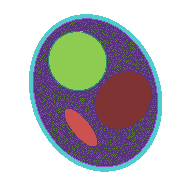

In [9]:
sim

## Sim parameters


In [ ]:
sim.simulationTime= 60*60
interval = 0.05
# sim.latticeWriteInterval=interval
# sim.speciesWriteInterval=interval
sim.latticeWriteInterval= int(interval/sim.timestep) # .05s
sim.speciesWriteInterval= int(interval/sim.timestep) # .05s
externalGal = 11.1e-3 # M
nRibosomes = np.sum(sim.siteLattice==reg.ribosomes.idx)
mrnaDiffusion = 0.05e-12

## species


In [ ]:
with sim.construct():
    sim.species('DGrep', texRepr='D_{GFP}', annotation="Reporter gene")
    sim.species('DGrep_G4d', texRepr="D_{GFP}{:}G_{4D}", annotation="Activated reporter gene")
    sim.species('DGrep_G4d_G80d', texRepr="D_{GFP}{:}G_{4D}{:}G_{80D}", annotation="Repressed reporter gene")
    sim.species('Grep', texRepr="GFP", annotation="GFP reporter")
    sim.species('Rrep', texRepr="m_{GFP}", annotation="Reporter mRNA")

In [ ]:
with sim.construct():
    sim.species('R1',texRepr='m_1', annotation="GAL1 mRNA")
    sim.species('DG1', texRepr='D_{1}', annotation="GAL1 gene")
    sim.species('DG1_G4d', texRepr="D_{1}{:}G_{4D}", annotation="Activated GAL1 gene")
    sim.species('DG1_G4d_G80d', texRepr="D_{1}{:}G_{4D}{:}G_{80D}", annotation="Repressed GAL1 gene")
    sim.species('G1', texRepr="G_1", annotation="Gal1p [galactokinase]")


In [ ]:
with sim.construct():
    sim.species('R2',texRepr='m_2', annotation="GAL2 mRNA")
    sim.species('DG2', texRepr='D_{2}', annotation="GAL2 gene")
    sim.species('DG2_G4d', texRepr="D_{2}{:}G_{4D}", annotation="Activated GAL2 gene")
    sim.species('DG2_G4d_G80d', texRepr="D_{2}{:}G_{4D}{:}G_{80D}", annotation="Repressed GAL2 gene")
    sim.species('G2', texRepr="G_2", annotation="Gal2p [permease]")

In [ ]:
with sim.construct():
    sim.species('R3',texRepr='m_3', annotation="GAL3 mRNA")
    sim.species('DG3', texRepr='D_{3}', annotation="GAL3 gene")
    sim.species('DG3_G4d', texRepr="D_{3}{:}G_{4D}", annotation="Activated GAL3 gene")
    sim.species('DG3_G4d_G80d', texRepr="D_{3}{:}G_{4D}{:}G_{80D}", annotation="Repressed GAL3 gene")
    sim.species('G3', texRepr="G_3", annotation="Gal3p [transcriptional regulator]")
    sim.species('G3i', texRepr="G^\star_3", annotation="Activated Gal3p (galactose bound)")

In [ ]:
with sim.construct():
    sim.species('DG4',texRepr='D_4', annotation="GAL4 gene")
    sim.species('R4',texRepr='m_4', annotation="GAL4 mRNA")
    sim.species('G4', texRepr="G_4", annotation="Gal4p monomer")
    sim.species('G4d', texRepr="G_{4D}", annotation="Gal4p dimer [transcription factor]")

In [ ]:
with sim.construct():
    sim.species('R80',texRepr='m_{80}', annotation="GAL80 mRNA")
    sim.species('DG80', texRepr='D_{80}', annotation="GAL80 gene")
    sim.species('DG80_G4d', texRepr="D_{G80}{:}G_{4D}", annotation="Activated GAL80 gene")
    sim.species('DG80_G4d_G80d', texRepr="D_{G80}{:}G_{4D}{:}G_{80D}", annotation="Repressed GAL80 gene")
    sim.species('G80', texRepr="G_{80}", annotation="Gal80p monomer") 
    sim.species('G80d', texRepr="G_{80D}", annotation="Gal80p dimer [inhibits Gal4p]")
    sim.species('G80d_G3i', texRepr="G_{80D}{:}d_G^\star_3", annotation="Complex of Gal3p(activated) and Gal80Cd")

In [ ]:
with sim.construct():
    sim.species('Rdummy', texRepr="m_d", annotation='Dummy mRNA')

In [ ]:
with sim.construct():
    sim.species('ribosome', texRepr="R", annotation="Inactive ribosome")
    sim.species('ribosomeD', texRepr="R{:}m_d", annotation="Ribosome translating dummy mRNA")
    sim.species('ribosomeG1', texRepr="R{:}m_1", annotation="Ribosome translating GAL1")
    sim.species('ribosomeG2', texRepr="R{:}m_2", annotation="Ribosome translating GAL2")
    sim.species('ribosomeG3', texRepr="R{:}m_3", annotation="Ribosome translating GAL3")
    sim.species('ribosomeG4', texRepr="R{:}m_4", annotation="Ribosome translating GAL4")
    sim.species('ribosomeG80', texRepr="R{:}m_{80}", annotation="Ribosome translating GAL80")
    sim.species('ribosomeGrep', texRepr="R{:}m_{GFP}", annotation="Ribosome translating GFP")

## reactions

In [ ]:
cellVol = 3.57e-14 # L
nav = cellVol*6.022e23
invMin2invSec = 1/60.0 # s^-1/min^-1
conv2ndOrder = invMin2invSec*nav
conv1stOrder = invMin2invSec

## dimerization

In [ ]:
with sim.construct():
    #sim.rateConst("fd", 0.001*conv2ndOrder, order=2, annotation="Gal4p/Gal80p dimerization")
    #sim.rateConst("rd", 100*conv1stOrder, order=1, annotation="Gal4p/Gal80p dimer dissociation")
    sim.rateConst("fd", 100*conv2ndOrder, order=2, annotation="Gal4p/Gal80p dimerization !!Transposed!!")
    sim.rateConst("rd", 0.001*conv1stOrder, order=1, annotation="Gal4p/Gal80p dimer dissociation !!Transposed!!")
    sim.reaction([sp.G4, sp.G4], [sp.G4d], rc.fd, regions=[reg.cytoplasm, reg.nucleoplasm])
    sim.reaction([sp.G4d], [sp.G4, sp.G4], rc.rd, regions=[reg.cytoplasm, reg.nucleoplasm])
    sim.reaction([sp.G80, sp.G80], [sp.G80d], rc.fd, regions=[reg.cytoplasm, reg.nucleoplasm])
    sim.reaction([sp.G80d], [sp.G80, sp.G80], rc.rd, regions=[reg.cytoplasm, reg.nucleoplasm])

## DNA binding

In [ ]:
with sim.construct():
    
    Kp4 = 0.2600 # 4 binding sites
    Kq4 = 1.1721 
    
    kf1_4 = 0.1
    kf2_4 = 0.1
    kr1_4 = kf1_4/Kp4
    kr2_4 = kf2_4/Kq4
    
    Kp5 = 0.0099 # 5 binding sites
    Kq5 = 0.7408 
    
    kf1_5 = 0.1
    kf2_5 = 0.1
    kr1_5 = kf1_5/Kp5
    kr2_5 = kf2_5/Kq5
    
    
    Kp = 0.0248 # 1 binding site
    Kq = 0.1885 
    kf1 = 0.1
    kr1 = kf1/Kp
    kf2 = 0.1
    kr2 = kf2/Kq

    #convBinding = invMin2invSec*sim.siteNAV

    sim.rateConst("f1", kf1*conv2ndOrder, order=2, annotation="Gene/Gal4p binding [1 site]")
    sim.rateConst("r1", kr1*conv1stOrder, order=1, annotation="Gene/Gal4p dissociation [1 site]")
    sim.rateConst("f2", kf2*conv2ndOrder, order=2, annotation="Gene/Gal80p binding [1 site]")
    sim.rateConst("r2", kr2*conv1stOrder, order=1, annotation="Gene/Gal80p dissociation [1 site]")
    
    sim.rateConst("f1_4", kf1_4*conv2ndOrder, order=2, annotation="Gene/Gal4p binding [4 sites]")
    sim.rateConst("r1_4", kr1_4*conv1stOrder, order=1, annotation="Gene/Gal4p dissociation [4 sites]")
    sim.rateConst("f2_4", kf2_4*conv2ndOrder, order=2, annotation="Gene/Gal80p binding [4 sites]")
    sim.rateConst("r2_4", kr2_4*conv1stOrder, order=1, annotation="Gene/Gal80p dissociation [4 sites]")
    
    sim.rateConst("f1_5", kf1_5*conv2ndOrder, order=2, annotation="Gene/Gal4p binding [5 sites]")
    sim.rateConst("r1_5", kr1_5*conv1stOrder, order=1, annotation="Gene/Gal4p dissociation [5 sites]")
    sim.rateConst("f2_5", kf2_5*conv2ndOrder, order=2, annotation="Gene/Gal80p binding [5 sites]")
    sim.rateConst("r2_5", kr2_5*conv1stOrder, order=1, annotation="Gene/Gal80p dissociation [5 sites]")

    dnas =      [sp.DG1,          sp.DG2,          sp.DG3,          sp.DG80,          sp.DGrep]
    mrnas =     [sp.R1,           sp.R2,           sp.R3,           sp.R80,           sp.Rrep]
    dnaActs =   [sp.DG1_G4d,      sp.DG2_G4d,      sp.DG3_G4d,      sp.DG80_G4d,      sp.DGrep_G4d]
    dnaDeacts = [sp.DG1_G4d_G80d, sp.DG2_G4d_G80d, sp.DG3_G4d_G80d, sp.DG80_G4d_G80d, sp.DGrep_G4d_G80d]
    f1s =       [rc.f1_4,         rc.f1_5,         rc.f1,           rc.f1,            rc.f1_4]
    f2s =       [rc.f2_4,         rc.f2_5,         rc.f2,           rc.f2,            rc.f2_4]
    r1s =       [rc.r1_4,         rc.r1_5,         rc.r1,           rc.r1,            rc.r1_4]
    r2s =       [rc.r2_4,         rc.r2_5,         rc.r2,           rc.r2,            rc.r2_4]
    
    terms = zip(dnas,mrnas,dnaActs,dnaDeacts,f1s,f2s,r1s,r2s)
    for dna,mrna,dnaAct,dnaDeact,f1,f2,r1,r2 in terms:
        sim.reaction([dna,sp.G4d], dnaAct, f1, regions=reg.nucleoplasm)
        sim.reaction(dnaAct, [dna,sp.G4d], r1, regions=reg.nucleoplasm)
        sim.reaction([dnaAct,sp.G80d], dnaDeact, f2, regions=reg.nucleoplasm)
        sim.reaction(dnaDeact, [dnaAct, sp.G80d], r2, regions=reg.nucleoplasm)

##  G3 activation

In [ ]:
with sim.construct():
    sim.rateConst("fi", 7.45e-7*conv2ndOrder, order=1, annotation="Gal3p activation; needs to be multiplied by [GAI] in mol/L")
    sim.rateConst("ri", 890.0*conv1stOrder, order=1, annotation="Gal3p deactivation")
    sim.rateConst("fd3i80", 0.025716*conv2ndOrder, order=2, annotation="Gal3p*/Gal80 association")
    sim.rateConst("dr3i80", 0.0159616*conv1stOrder, order=1, annotation="Gal3p*/Gal80 disassociation")
    sim.rateConst("dp_gal3", 0.01155*conv1stOrder, order=1, annotation="GAL3 degradation")
    sim.rateConst("dp_gal3gal80", 0.5*rc.dp_gal3.value, order=1, annotation="Gal3p*:Gal80 degradation")

    #sim.reaction([sp.G3, sp.GAI], sp.G3i, rc.fi, regions=reg.cytoplasm)
    sim.reaction(sp.G3, sp.G3i, rc.fi, regions=reg.cytoplasm) # XXX Hybrid in RDME
    #sim.reaction(sp.G3i, [sp.G3, sp.GAI], rc.ri, regions=intracellular)
    sim.reaction(sp.G3i, sp.G3, rc.ri, regions=reg.cytoplasm) # XXX Modified in RDME
    sim.reaction(sp.G3i, [], rc.dp_gal3, regions=reg.cytoplasm)
    sim.reaction([sp.G3i, sp.G80d], [sp.G80d_G3i], rc.fd3i80, regions=reg.cytoplasm)
    sim.reaction([sp.G80d_G3i], [sp.G3i, sp.G80d], rc.dr3i80, regions=reg.cytoplasm)
    sim.reaction([sp.G80d_G3i], [], rc.dp_gal3gal80, regions=reg.cytoplasm)

## Transcription 

In [ ]:
with sim.construct():
    sim.rateConst("alpha1", 0.7379*conv1stOrder, order=1, annotation='GAL1 transcription')
    sim.rateConst("alpha2", 2.542*conv1stOrder, order=1, annotation='GAL2 transcription')
    sim.rateConst("alpha3", 0.571429*0.7465*conv1stOrder, order=1, annotation='GAL3 transcription')
    sim.rateConst("ir_gal4", 0.009902*conv1stOrder, order=1, annotation='GAL4 transcription')
    sim.rateConst("alpha_rep", 1.1440*conv1stOrder, order=1, annotation='GFP transcription')
    sim.rateConst("alpha80", 0.6065*conv1stOrder, order=1, annotation='GAL80 transcription')

    sim.rateConst("dr_gal1", 0.02236*conv1stOrder, order=1, annotation='GAL1 mRNA degradation')
    sim.rateConst("dr_gal2", 0.07702*conv1stOrder, order=1, annotation='GAL2 mRNA degradation')
    sim.rateConst("dr_gal3", 0.02666*conv1stOrder, order=1, annotation='GAL3 mRNA degradation')
    sim.rateConst("dr_gal4", 0.02476*conv1stOrder, order=1, annotation='GAL4 mRNA degradation')
    sim.rateConst("dr_rep", 0.03466*conv1stOrder, order=1, annotation='GFP mRNA degradation')
    sim.rateConst("dr_gal80", 0.02888*conv1stOrder, order=1, annotation='GAL80 mRNA degradation')

    tss =   [rc.alpha1,   rc.alpha2,   rc.alpha3,   rc.ir_gal4,  rc.alpha_rep, rc.alpha80] 
    dcys =  [rc.dr_gal1,  rc.dr_gal2,  rc.dr_gal3,  rc.dr_gal4,  rc.dr_rep,    rc.dr_gal80]
    genes = [sp.DG1_G4d,  sp.DG2_G4d,  sp.DG3_G4d,  sp.DG4,      sp.DGrep_G4d, sp.DG80_G4d]
    mrnas = [sp.R1,       sp.R2,       sp.R3,       sp.R4,       sp.Rrep,     sp.R80]

    for ts,dcy,gene,mrna in zip(tss, dcys, genes, mrnas):
        sim.reaction(gene, [gene, mrna], ts, regions=reg.nucleoplasm)
        sim.reaction(mrna,[], dcy, regions=[reg.cytoplasm, reg.nucleoplasm, reg.ribosomes])

    otherMrna = 0.5*(6100+18300) #102988
    otherMrnaDecay = np.log(2)/60/20 # 100205
    tsOther = otherMrna*otherMrnaDecay/reg.nucleoplasm.volume/sim.NA
    
    sim.rateConst("dummyTs", tsOther, order=0, annotation='Dummy mRNA transcription')
    sim.rateConst("dummyDeg", otherMrnaDecay, order=1, annotation='Dummy mRNA degradation')
    sim.reaction([], sp.Rdummy, rc.dummyTs, regions=reg.nucleoplasm)
    sim.reaction(sp.Rdummy, [], rc.dummyDeg, regions=[reg.cytoplasm, reg.nucleoplasm, reg.ribosomes])


## Translation

In [ ]:
with sim.construct():
    #tlInitDet = 100e6 # 10.1016/j.molcel.2006.02.014 [eco]
    tlInitDet = 0.2 * 2000 * mrnaDiffusion * sim.NA * sim.latticeSpacing
    sim.rateConst("rib_assoc", tlInitDet, order=2, annotation='mRNA/Ribosome association rate') # TODO
    
    otherProtein = 5e7 #106198
    otherProtDecay = np.log(2)/60/43 # 104151
    tlOther = otherProtDecay*otherProtein/otherMrna
    sim.rateConst("dummyTl", tlOther, order=1, annotation="Dummy mRNA translation")

    sim.rateConst("ip_gal1", 1.9254*conv1stOrder, order=1, annotation='GAL1 translation')
    sim.rateConst("ip_gal2", 13.4779*conv1stOrder, order=1, annotation="GAL2 translation")
    sim.rateConst("ip_gal3", 55.4518*conv1stOrder, order=1, annotation="GAL3 translation")
    sim.rateConst("ip_gal4", 10.7091*conv1stOrder, order=1, annotation="GAL4 translation")
    sim.rateConst("ip_rep", 5.7762*conv1stOrder, order=1, annotation="GFP translation")
    sim.rateConst("ip_gal80", 3.6737*conv1stOrder, order=1, annotation="GAL80 translation")

    sim.rateConst("dp_gal1", 0.003851*conv1stOrder, order=1, annotation='GAL1 degradation')
    sim.rateConst("dp_gal2", 0.003851*conv1stOrder, order=1, annotation="GAL2 degradation")
    sim.rateConst("dp_gal3", 0.01155*conv1stOrder, order=1, annotation="GAL3 degradation")
    sim.rateConst("dp_gal4", 0.006931*conv1stOrder, order=1, annotation="GAL4 degradation")
    sim.rateConst("dp_rep", 0.01155*conv1stOrder, order=1, annotation="GFP degradation")
    sim.rateConst("dp_gal80", 0.006931*conv1stOrder, order=1, annotation="GAL80 degradation")

    ktls =                 [rc.ip_gal1,    rc.ip_gal2,    rc.ip_gal3,    rc.ip_gal4,    rc.ip_rep,       rc.ip_gal80]
    dcys =                 [rc.dp_gal1,    rc.dp_gal2,    rc.dp_gal3,    rc.dp_gal4,    rc.dp_rep,       rc.dp_gal80] 
    mdcys =                [rc.dr_gal1,  rc.dr_gal2,  rc.dr_gal3,  rc.dr_gal4,  rc.dr_rep,    rc.dr_gal80]
    translatingRibosomes = [sp.ribosomeG1, sp.ribosomeG2, sp.ribosomeG3, sp.ribosomeG4, sp.ribosomeGrep, sp.ribosomeG80]
    prots =                [sp.G1,         sp.G2,         sp.G3,         sp.G4,         sp.Grep,         sp.G80]
    compartments =         [[reg.ribosomes, reg.cytoplasm], 
                            [reg.ribosomes, reg.cytoplasm, reg.plasmaMembrane], 
                            [reg.ribosomes, reg.cytoplasm], 
                            [reg.ribosomes, reg.cytoplasm, reg.nucleoplasm], 
                            [reg.ribosomes, reg.cytoplasm], 
                            [reg.ribosomes, reg.cytoplasm, reg.nucleoplasm]]


    for mrna, translatingRibosome, prot, ktl, dcy,mdcy,rgs in zip(mrnas, translatingRibosomes, prots, ktls, dcys, mdcys,compartments):
        sim.reaction([sp.ribosome, mrna], [translatingRibosome], rc.rib_assoc, regions=reg.ribosomes)
        sim.reaction([translatingRibosome], [sp.ribosome, mrna, prot], ktl, regions=reg.ribosomes)
        sim.reaction([translatingRibosome], [sp.ribosome], mdcy, regions=reg.ribosomes)
    
    sim.reaction([sp.ribosome, sp.Rdummy], sp.ribosomeD, rc.rib_assoc, regions=reg.ribosomes)
    sim.reaction(sp.ribosomeD, [sp.ribosome, sp.Rdummy], rc.dummyTl, regions=reg.ribosomes)
    sim.reaction(sp.ribosomeD, sp.ribosome, rc.dummyDeg, regions=reg.ribosomes)
    

## protein degradation

In [ ]:
with sim.construct():
    sim.rateConst("dp_gal1", 0.003851*conv1stOrder, order=1, annotation='GAL1 degradation')
    sim.rateConst("dp_gal2", 0.003851*conv1stOrder, order=1, annotation="GAL2 degradation")
    sim.rateConst("dp_gal3", 0.01155*conv1stOrder, order=1, annotation="GAL3 degradation")
    sim.rateConst("dp_gal4", 0.006931*conv1stOrder, order=1, annotation="GAL4 degradation")
    sim.rateConst("dp_rep", 0.01155*conv1stOrder, order=1, annotation="GFP degradation")
    sim.rateConst("dp_gal80", 0.006931*conv1stOrder, order=1, annotation="GAL80 degradation")

    for prot, dcy,rgs in zip(prots, dcys, compartments):
        sim.reaction(prot,[], dcy, regions=rgs)

## Initial conditions

In [ ]:
if True:
    initMolec = pickle.load(open("ysZeroGAE.pkl", "rb"))
    volScale = np.sum(B.convexHull(sim.siteLattice==reg.plasmaMembrane.idx))*sim.siteV/cellVol
    def initMol(x):
        v = int(initMolec[x]*volScale)
        print(x, v)
        return int(initMolec[x]*volScale)
    #
    sp.DG4.placeNumberInto(reg.nucleoplasm, 1)
    for b in ["DG1", "DG2", "DG3", "DGrep", "DG80"]:
        ops = [b+x for x in ["", "_G4d", "_G4d_G80d"]]
        spName = max(ops, key=lambda x:initMolec[x])
        print("{} in state {}".format(b, spName))
        sim.species(spName).placeNumberInto(reg.nucleoplasm, 1)
    #
    sp.G1.placeNumberInto(reg.cytoplasm, initMol("G1"))
    sp.G2.placeNumberInto(reg.plasmaMembrane, initMol("G2"))
    sp.G3.placeNumberInto(reg.cytoplasm, initMol("G3"))
    sp.G4d.placeNumberInto(reg.nucleoplasm, initMol("G4d"))
    sp.Grep.placeNumberInto(reg.cytoplasm, initMol("Grep"))
    
    sp.Rdummy.placeNumberInto(reg.cytoplasm, int(otherMrna))

    cscl = reg.cytoplasm.volume/(reg.cytoplasm.volume+reg.nucleoplasm.volume)
    totM = initMol("G80C") + initMol("G80")
    totD = initMol("G80Cd") + initMol("G80d")
    sp.G80.placeNumberInto(reg.cytoplasm, int(cscl*totM))
    sp.G80.placeNumberInto(reg.nucleoplasm, int((1-cscl)*totM))
    sp.G80d.placeNumberInto(reg.cytoplasm, int(cscl*totD))
    sp.G80d.placeNumberInto(reg.nucleoplasm, int((1-cscl)*totD))
    for x,y,z in np.argwhere(sim.siteLattice==reg.ribosomes.idx):
        sp.ribosome.placeParticle(x,y,z,1)
else:
    
    sim.copyParticleLattice("icLattice.lm", diffusion_model=True)
    
    
    #sim.copyParticleLattice("../../sim/initial_conditions.lm",frame=10,replicate=1)

# Diffusion

In [ ]:
with sim.construct():
    sim.transitionRate(None, None, None, sim.diffusionZero)

## mRNA

In [ ]:
with sim.construct():
    sim.diffusionConst("mrna", mrnaDiffusion, texRepr=r'D_{mRNA}', annotation='Generic mRNA')

    for mrna in sim.speciesList.matchRegex("R.*"):
        sim.transitionRate(mrna, reg.nucleoplasm, reg.cytoplasm, dc.mrna)
        sim.transitionRate(mrna, reg.cytoplasm, reg.nucleoplasm, sim.diffusionZero)
        sim.transitionRate(mrna, reg.nucleoplasm, reg.nucleoplasm, dc.mrna)
        sim.transitionRate(mrna, reg.cytoplasm, reg.cytoplasm, dc.mrna)
        sim.transitionRate(mrna, reg.ribosomes, reg.ribosomes, dc.mrna)
        sim.transitionRate(mrna, reg.ribosomes, reg.cytoplasm, dc.mrna)
        sim.transitionRate(mrna, reg.cytoplasm, reg.ribosomes, dc.mrna)

## DNA

In [ ]:
with sim.construct():
    for sps in sim.speciesList.matchRegex("D.*"):
        sps.diffusionRate(None, sim.diffusionZero)

## Ribosome Occlusion

In [ ]:
with sim.construct():
    sim.diffusionConst("prot", 1e-12, texRepr=r'D_{prot}', annotation='Generic protein')
    for sps in [sp.G1, sp.G2, sp.G3, sp.G3i, sp.G4, sp.G4d, sp.G80, sp.G80d, sp.G80d_G3i, sp.Grep]:
        sps.diffusionRate(reg.cytoplasm, dc.prot)
        sim.transitionRate(sps, reg.ribosomes, reg.cytoplasm, sim.diffusionFast)
        sim.transitionRate(sps, reg.cytoplasm, reg.ribosomes, sim.diffusionZero)

## Transcription Factors

In [ ]:
with sim.construct():
    for sps in [sp.G4d, sp.G4d, sp.G80, sp.G80d]:
        sps.diffusionRate(reg.nucleoplasm, dc.prot)
        sim.transitionRate(sps, reg.nucleoplasm, reg.cytoplasm, dc.prot)
        sim.transitionRate(sps, reg.cytoplasm, reg.nucleoplasm, dc.prot)

## Cytoplasmic Protein

In [ ]:
with sim.construct():
    for sps in [sp.G1, sp.G2, sp.G3, sp.G3i, sp.G80d_G3i, sp.Grep]:
        sim.transitionRate(sps, reg.cytoplasm, reg.nucleoplasm, sim.diffusionZero) 

## transporter

In [ ]:
with sim.construct():
    sim.transitionRate(sp.G2, reg.cytoplasm, reg.plasmaMembrane, dc.prot)
    sim.transitionRate(sp.G2, reg.plasmaMembrane, reg.cytoplasm, sim.diffusionZero)
    sim.diffusionConst("mem", 0.01e-12, texRepr=r'D_{mem}', annotation='Generic protein on membrane')
    sp.G2.diffusionRate(reg.plasmaMembrane, dc.mem)

## Ribosomes

In [ ]:
with sim.construct():
    for sps in sim.speciesList.matchRegex("ribosome.*"):
        sim.transitionRate(sps, None, None, sim.diffusionZero)

In [ ]:
sim.showAllSpecies()

## Hybrid Model

In [ ]:
import pyximport
pyximport.install(setup_args={ "include_dirs":np.get_include()})
from ode import RHS

In [ ]:
class OdeRdmeHybridSolver:
    """Hybrid solver for Galactose switch
    
    Transport reactions and galactose metabolism handled by ODE, rest by RDME. The
    ODE system is coupled to the RDME by updating the protein counts in the ODE 
    each communication step. New proteins are added to the state unbound to
    galactose. If the number of proteins decreases, both bound and unbound 
    states are decreased by the same proportion and the galactose is
    added back as internal or external galactose. The RDME is coupled to the 
    ODE system through the internal galactose concentration. The rate of
    G3 -> G3i is updated with the internal galactose concentration each
    communication step."""
    def copyInitialConditions(self, cts):
        y = np.zeros(len(self.odeSpNames))
        y[self.odeSpIndex("GAI")] = 0
        y[self.odeSpIndex("G1")] = cts['countBySpecies'][self.rdme.sp.G1]/self.NAV # XXX think about which volume
        y[self.odeSpIndex("G1GAI")] = 0
        y[self.odeSpIndex("G2")] = cts['countBySpecies'][self.rdme.sp.G2]/self.NAV
        y[self.odeSpIndex("G2GAE")] = 0
        y[self.odeSpIndex("G2GAI")] = 0
        self.boundGal = self.rdmeGal(cts)
        return y
  
    def rdmeGal(self, cts):
        return (cts['countBySpecies'][self.rdme.sp.G3i] + cts['countBySpecies'][self.rdme.sp.G80d_G3i])/self.NAV

    def rdme2odeConc(self, y0, cts):
        y = y0.copy()
        
        g1ode = y0[self.odeSpIndex("G1")]
        g1gaiode = y0[self.odeSpIndex("G1GAI")]
        g1rdme = cts['countBySpecies'][self.rdme.sp.G1]/self.NAV
        
        change = g1rdme-g1ode-g1gaiode
        
        if change > 0:
            y[self.odeSpIndex("G1")] = g1ode + change
        else:
            fracChange = g1rdme/(g1ode+g1gaiode)
            y[self.odeSpIndex("G1")] = g1ode*fracChange
            y[self.odeSpIndex("G1GAI")] = g1gaiode*fracChange
            y[self.odeSpIndex("GAI")] += g1gaiode*(1-fracChange)
            
        
        g2ode = y0[self.odeSpIndex("G2")]
        g2gaiode = y0[self.odeSpIndex("G2GAI")]
        g2gaeode = y0[self.odeSpIndex("G2GAE")]
        g2rdme = cts['countBySpeciesRegion'][self.rdme.sp.G2][self.rdme.reg.plasmaMembrane]/self.NAV
        
        change = g2rdme-g2ode-g2gaiode-g2gaeode
        
        if change >= 0:
            y[self.odeSpIndex("G2")] = g2ode + change
        else:
            fracChange = g2rdme/(g2ode+g2gaiode+g2gaeode)
            y[self.odeSpIndex("G2")] = g2ode*fracChange
            y[self.odeSpIndex("G2GAI")] = g2gaiode*fracChange
            y[self.odeSpIndex("GAI")] += g2gaiode*(1-fracChange)
            y[self.odeSpIndex("G2GAE")] = g2gaeode*fracChange
            
        g0 = self.boundGal
        g1 = self.rdmeGal(cts)
        y[self.odeSpIndex("GAI")] += g1-g0
        self.boundGal = g1
            
        return y
        
    def __init__(self, lmFile, initialExternalGalactose):
        super(OdeRdmeHybridSolver, self).__init__()
        self.GAE = initialExternalGalactose
        self.odeYs = None
        self.lastOdeEval = 0
        self.odeEvals = []
        if isinstance(lmFile, (RDMEFile, RDMESim)):
            self.rdme = lmFile
        else:
            self.rdme = RDME.File(lmFile)
        self.cellVol = self.rdme.reg.cytoplasm.volume + self.rdme.reg.nucleoplasm.volume + self.rdme.reg.plasmaMembrane.volume
        self.NAV = 6.022e23*self.cellVol
        self.buildOdeSys(
                 [[["G1","GAI"],  ["G1GAI"],     1.442e5],
                  [["G1GAI"],     ["G1", "GAI"], 30.708],
                  [["G1GAI"],     ["G1"],        55.833],
                  [["G2GAI"],     ["G2GAE"],     72.5],
                  [["G2GAE"],     ["G2GAI"],     72.5],
                  [["G2GAE"],     ["G2"], 39.875],
                  [["G2"],        ["G2GAE"],     1.123e5*self.GAE],
                  [["G2", "GAI"], ["G2GAI"],     1.123e5],
                  [["G2GAI"],     ["G2", "GAI"], 39.875]])
        
                  
        self.g3actRidx = self.rdme.reaction(self.rdme.sp.G3, self.rdme.sp.G3i, self.rdme.rc.fi).idx
        self.g3actRc = self.rdme.rc.fi._toLM()
     
                   
    def hookSimulation(self, t, lattice):
        cts = self.rdme.particleStatistics(particleLattice=lattice.getParticleLatticeView(),
                                           siteLattice=lattice.getSiteLatticeView())
        if self.odeYs is None:
            ys0 = self.copyInitialConditions(cts)
        else:
            ys0 = self.rdme2odeConc(self.odeYs, cts)
                   
        dt = t-self.lastOdeEval
        if dt>0:
            ys1 = self.stepOde(dt, ys0)
        else:
            ys1 = ys0
            
        self.odeEvals.append((t,ys1))
        self.odeYs = ys1
        self.lastOdeEval = t
            
        assocRt = max(0,self.g3actRc*ys1[self.odeSpIndex("GAI")])
        self.setReactionRate(self.g3actRidx, assocRt)
        
        print("="*80)
        print("t=",t)
        print("ODE")
        for i,n in enumerate(self.odeSpNames):
            print("  {:<16s}{:16.5g}".format(n,self.odeYs[i]))
        print("RDME")
        for n in self.rdme.speciesList:
            print("  {:<16s}{:16d}".format(n.name,cts['countBySpecies'][n]))
        print("new rate: {:.3g}".format(assocRt))
        print("-"*80)
        
        return 0

    def odeSpIndex(self, sp):
        return self.odeSpNames.index(sp)
    
    def buildOdeSys(self, rxns):
        odeSpNames = set()
        for react, prod, _ in rxns:
            odeSpNames |= set(prod) | set(react)
        nsp = len(odeSpNames)
        nrxn = len(rxns)
        stoch = np.zeros((nrxn, nsp), dtype=np.int32)
        dep = np.zeros((nrxn, nsp), dtype=np.int32)
        ks = np.zeros(nrxn, dtype=np.float64)
        self.odeSpNames = sorted(odeSpNames)
        for i, (react, prod, rate) in enumerate(rxns):
            ks[i] = rate
            for r in react:
                dep[i, self.odeSpIndex(r)] += 1
                stoch[i, self.odeSpIndex(r)] -= 1
            for p in prod:
                stoch[i, self.odeSpIndex(p)] += 1
        self.odeStoch = stoch
        self.odeDep = dep
        self.odeKs = ks
    
    def stepOde(self, t, ys0):
        rhs = RHS(self.odeStoch, self.odeDep, self.odeKs)
        ts = np.linspace(0,t, 10)
        ys = spint.odeint(rhs.evaluate, ys0, ts)
        return ys[-1,:]

In [ ]:
Solver = makeSolver(IntMpdRdmeSolver, OdeRdmeHybridSolver)
solver = Solver(sim, externalGal)

In [ ]:
sim.finalize()

In [ ]:
try:
    traj = sim.run(solver=solver, cudaDevices=[0])
finally:
    odeData = dict(ts=np.array([x[0] for x in solver.odeEvals]),
                   ys=np.array([x[1] for x in solver.odeEvals]),
                   names=solver.odeSpNames)

    pickle.dump(odeData, open(traj.filename+".pkl", "wb"))